# 2.2 画像の前処理

In [2]:
import os
import ffmpeg

input_directory = os.path.join(os.getcwd(), "GP030003_eye3_crop.MP4")
output_directory = os.path.join(os.getcwd(), "ori_images")
output_fps = 2

In [3]:
# 出力ディレクトリが存在しない場合、作成する
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# フレームレート２で動画から画像を取り出す
os.system(f'yes | ffmpeg -i {input_directory} -vcodec png -r {output_fps} {os.path.join(output_directory, "%04d.png")}')

ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --e

0

47
(47, 128)


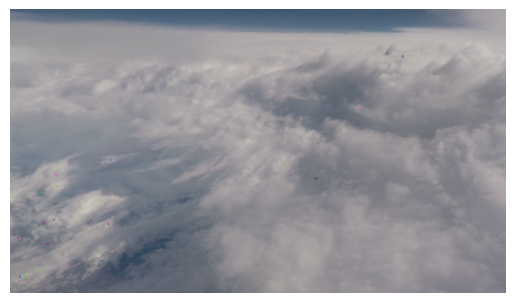

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 画像を読み込む
image = cv2.imread(os.path.join(output_directory, "0001.png"))

img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# SIFT特徴量抽出器を作成
sift = cv2.SIFT_create()

# 画像からSIFTキーポイントと記述子を抽出
keypoints, descriptors = sift.detectAndCompute(img, None)

print(len(keypoints))
print(descriptors.shape)
# 画像にキーポイントを描画
image_with_keypoints = cv2.drawKeypoints(image, keypoints, None)

# OpenCVはデフォルトでBGRのカラーチャンネルを使用するため、RGBに変換する
image_rgb = cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB)

# 画像をMatplotlibで表示
plt.imshow(image_rgb)
plt.axis('off')  # 軸を非表示にする（オプション）
plt.show()
plt.imsave(os.path.join(os.getcwd(), "sift_ori.png"),image_rgb)

# 　コントラスト制限付適応ヒストグラム

(842, 128)


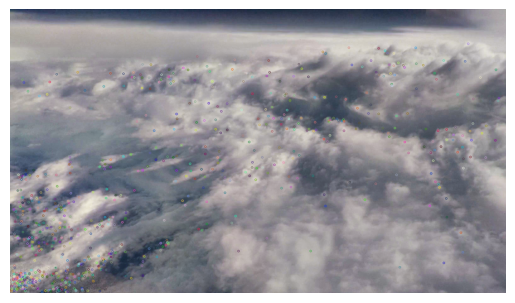

In [5]:
import cv2
import numpy as np

# コントラスト調整の強さ
nb = 2.0

src = cv2.imread(os.path.join(output_directory, "0001.png"))

src_r = src[:,:,2]
src_g = src[:,:,1]
src_b = src[:,:,0]

clahe = cv2.createCLAHE(clipLimit=nb, tileGridSize=(8, 8))

# 適用的ヒストグラム平坦化(4x4)
cl0_r = clahe.apply(src_r)
cl0_g = clahe.apply(src_g)
cl0_b = clahe.apply(src_b)
cl0 = cv2.merge((cl0_b,cl0_g,cl0_r))

#img = cv2.cvtColor(cl0, cv2.COLOR_BGR2RGB)
img = cv2.cvtColor(cl0, cv2.COLOR_BGR2GRAY)

# SIFT特徴量抽出器を作成
sift = cv2.SIFT_create()

# 画像からSIFTキーポイントと記述子を抽出
keypoints, descriptors = sift.detectAndCompute(img, None)

print(descriptors.shape)

image_with_keypoints = cv2.drawKeypoints(cl0, keypoints, None)
cv2.imwrite(os.path.join(os.getcwd(), f"contrast{nb}.png"), image_with_keypoints)
image_rgb = cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')  # 軸を非表示にする（オプション）
plt.show()

(708, 128)


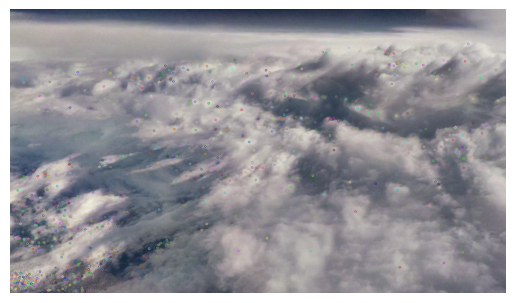

In [6]:
import cv2
import numpy as np

nb = 2.0
kernel_size = 3

src = cv2.imread(os.path.join(output_directory, "0001.png"))

src_r = src[:,:,2]
src_g = src[:,:,1]
src_b = src[:,:,0]

clahe = cv2.createCLAHE(clipLimit=nb, tileGridSize=(8, 8))

# 適用的ヒストグラム平坦化(4x4)
cl0_r = clahe.apply(src_r)
cl0_g = clahe.apply(src_g)
cl0_b = clahe.apply(src_b)
cl0 = cv2.merge((cl0_b,cl0_g,cl0_r))

# メディアンフィルタの適用
median_filtered = cv2.medianBlur(cl0, kernel_size)

#img = cv2.cvtColor(cl0, cv2.COLOR_BGR2RGB)
img = cv2.cvtColor(median_filtered, cv2.COLOR_BGR2GRAY)

# SIFT特徴量抽出器を作成
sift = cv2.SIFT_create()

# 画像からSIFTキーポイントと記述子を抽出
keypoints, descriptors = sift.detectAndCompute(img, None)

print(descriptors.shape)

image_with_keypoints = cv2.drawKeypoints(cl0, keypoints, None)
cv2.imwrite(os.path.join(os.getcwd(), f"contrast{nb}&medianfilterd{int(kernel_size)}.png"), image_with_keypoints)
image_rgb = cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')  # 軸を非表示にする（オプション）
plt.show()

全画像の前処理

In [8]:
import os
import cv2

# 入力画像ディレクトリと出力ディレクトリを指定します。
input_directory = os.path.join(os.getcwd(), "ori_images")
output_directory = os.path.join(os.getcwd(), "images")

nb = 2.0

# カーネルサイズの指定
kernel_size = 3  # 任意のカーネルサイズを指定

# 画像データの範囲を指定します。0001~0150.pngの画像が存在する場合。
start_frame = 1
end_frame = len(os.listdir(input_directory))
feature_num = 0
feature_num_rgb = 0
# 出力ディレクトリが存在しない場合、作成します。
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# 画像データを処理します。
for frame_number in range(start_frame, end_frame + 1):
    # 画像ファイルのパスを生成します。
    image_path = os.path.join(input_directory, f"{frame_number:04d}.png")

    src = cv2.imread(image_path)

    src_r = src[:,:,2]
    src_g = src[:,:,1]
    src_b = src[:,:,0]

    clahe = cv2.createCLAHE(clipLimit=nb, tileGridSize=(8, 8))

    # 適用的ヒストグラム平坦化(4x4)
    cl0_r = clahe.apply(src_r)
    cl0_g = clahe.apply(src_g)
    cl0_b = clahe.apply(src_b)
    cl0 = cv2.merge((cl0_b,cl0_g,cl0_r))

    # メディアンフィルタの適用
    median_filtered = cv2.medianBlur(cl0, kernel_size)

    # SIFT特徴量抽出器を作成
    sift = cv2.SIFT_create()

    # 画像からSIFTキーポイントと記述子を抽出
    keypoints, descriptors = sift.detectAndCompute(median_filtered, None)

    feature_num_rgb += len(keypoints)
    # 出力ファイルのパスを生成します。
    output_path = os.path.join(output_directory, f"{frame_number:04d}.png")

    # 画像を保存します。
    cv2.imwrite(output_path, median_filtered)

(714, 128)


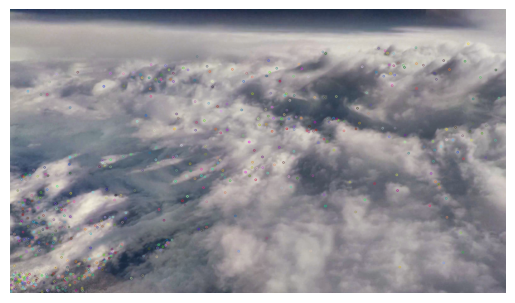

In [9]:
import cv2

# 画像の読み込み
image = cv2.imread(os.path.join(output_directory, "0001.png"))

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# SIFT特徴量抽出器を作成
sift = cv2.SIFT_create()

# 画像からSIFTキーポイントと記述子を抽出
keypoints, descriptors = sift.detectAndCompute(image, None)

print(descriptors.shape)
# 画像にキーポイントを描画
image = cv2.drawKeypoints(image, keypoints, None)
# 結果の表示
plt.imshow(image)
plt.axis('off')  # 軸を非表示にする（オプション）
plt.show()


# 2.3 Colmapを用いたカメラ座標の推定と撮影カメラのGPSデータとの地理的位置合わせ

In [2]:
script_directory = '/home/rc/instant-ngp'
os.system(f'yes | python {os.path.join(script_directory, "scripts", "colmap2nerf2.py")} --colmap_matcher sequential --run_colmap --aabb_scale 4 --images {os.path.join(os.getcwd(), "images")} --campose {os.path.join(os.getcwd(), "campose.txt")} --out {os.path.join(os.getcwd(), "transforms.json")} --colmap_db {os.path.join(os.getcwd(), "colmap.db")} --text {os.path.join(os.getcwd(), "colmap_text")} --mvgps {os.path.join(os.getcwd(), "mvgps.txt")}')

running colmap with:
	db=/media/rc/Earth/instant-ngp/eye/colmap.db
	images="/media/rc/Earth/instant-ngp/eye/images"
	sparse=/media/rc/Earth/instant-ngp/eye/colmap_sparse
	text=/media/rc/Earth/instant-ngp/eye/colmap_text
warning! folders '/media/rc/Earth/instant-ngp/eye/colmap_sparse' and '/media/rc/Earth/instant-ngp/eye/colmap_text' will be deleted/replaced. continue? (Y/n)==== running: colmap feature_extractor --ImageReader.camera_model OPENCV --ImageReader.camera_params "" --SiftExtraction.estimate_affine_shape=true --SiftExtraction.domain_size_pooling=true --ImageReader.single_camera 1 --database_path /media/rc/Earth/instant-ngp/eye/colmap.db --image_path "/media/rc/Earth/instant-ngp/eye/images"

Feature extraction

Processed file [1/1050]
  Name:            0001.png
  Dimensions:      1574 x 900
  Camera:          #1 - OPENCV
  Focal Length:    1888.80px
  Features:        2168
Processed file [2/1050]
  Name:            0004.png
  Dimensions:      1574 x 900
  Camera:          #1 -

yes: 標準出力: Broken pipe


0